# Business and Product Analytics

A product review asks the same questions every quarter: where the revenue comes from and whether the mix is changing, which segments and channels carry it, where prospective customers drop out, when they arrive, whether the ones who pay stay, and what ships next. This page walks one product through those questions and names the figure that answers each, so the chart to reach for arrives with the question rather than the other way round. Every figure links to the chart guide that covers it in full.

The product is a **simulated** subscription service with three plans, followed from January 2023 to December 2025: its monthly recurring revenue per plan, its new customers per acquisition channel and quarter, its 2025 revenue by region and industry, the 2025 sign-up funnel, every day's sign-ups, the retention of each month's paying cohort, and the roadmap for the first half of 2026. It is one seeded numpy draw in a hidden cell, so every docs build produces the same figures, and it stands in for any product with a funnel, a revenue mix and a roadmap.

In [1]:
from datetime import date, timedelta

import numpy as np

from datachart.charts import (
    BumpChart,
    CalendarHeatmap,
    GanttChart,
    Heatmap,
    SankeyChart,
    StackedAreaChart,
    Treemap,
)
from datachart.constants import (
    ASPECT_RATIO,
    FIG_SIZE,
    GANTT_DATE_PERIOD,
    GANTT_VALUE,
    LEGEND_LOCATION,
    SHOW_GRID,
    VALUE_FORMAT,
)
from datachart.utils import Grid

The hidden cell below holds the whole simulation. `mrr` is the monthly recurring revenue of each of the `PLANS` over the 36 `MONTHS`, in thousands of dollars; `new_customers` counts the customers each of the `CHANNELS` brought in per quarter; `REGIONS` nests the 2025 revenue by region and industry; `FUNNEL` is the 2025 funnel from sign-up on, as (from, to, people) steps; `signups` is the sign-ups on each of the `DAYS` of 2025; `retention` is the share of each of the `COHORTS` still paying k months after its first payment; and `ROADMAP` is the task list of the first half of 2026. The sections that follow only reshape those into the records the charts take.

In [2]:
# Every number below is simulated: one illustrative subscription product over
# 2023-2025, seeded so every docs build draws the same figures.
rng = np.random.default_rng(20260922)

PLANS = ["Starter", "Team", "Enterprise"]
PRICE = {"Starter": 29, "Team": 99, "Enterprise": 499}
MONTHS = [date(2023 + index // 12, index % 12 + 1, 1) for index in range(36)]

# --- customers per plan per month: a saturating self-serve tier, an accelerating
# mid tier, and an enterprise tier that ramps once a sales team is hired ---
_t = np.arange(len(MONTHS))
_customers = {
    "Starter": 400 + 900 / (1 + np.exp(-(_t - 10) / 5)),
    "Team": 60 + 22 * _t + 0.35 * _t**2,
    "Enterprise": np.where(_t < 14, 3 + 0.3 * _t, 7 + 4.2 * (_t - 14)),
}
# monthly recurring revenue per plan, in thousands of dollars
mrr = {
    plan: np.round(_customers[plan] * PRICE[plan] / 1000 * rng.normal(1, 0.02, _t.size), 1)
    for plan in PLANS
}

# --- new customers per acquisition channel per quarter ---
QUARTERS = [f"{year} Q{quarter}" for year in (2024, 2025) for quarter in (1, 2, 3, 4)]
_channel_trend = {
    # (start, end): the channel's new customers in the first and last quarter
    "Organic search": (310, 380),
    "Paid search": (340, 180),
    "Referral": (150, 260),
    "Partner": (60, 420),
    "Content": (120, 240),
    "Outbound": (180, 150),
}
CHANNELS = list(_channel_trend)
new_customers = {
    channel: np.round(
        np.linspace(start, end, len(QUARTERS)) * rng.normal(1, 0.06, len(QUARTERS))
    ).astype(int)
    for channel, (start, end) in _channel_trend.items()
}

# --- 2025 revenue by region and industry, in thousands of dollars ---
REGIONS = {
    "Europe": {"Software": 610, "Finance": 380, "Healthcare": 210, "Education": 150, "Retail": 120, "Other": 190},
    "North America": {"Software": 720, "Finance": 300, "Healthcare": 260, "Education": 90, "Retail": 170, "Other": 140},
    "Asia-Pacific": {"Software": 260, "Finance": 140, "Healthcare": 60, "Education": 70, "Retail": 90, "Other": 80},
    "Latin America": {"Software": 90, "Finance": 40, "Education": 50, "Retail": 30, "Other": 40},
}

# --- the 2025 funnel from sign-up on, in people; 240,000 visitors came before it ---
VISITORS = 240_000
FUNNEL = [
    ("Signed up", "Started a trial", 11000),
    ("Signed up", "Never activated", 7400),
    ("Started a trial", "Paid", 3100),
    ("Started a trial", "Trial expired", 7900),
    ("Paid", "Active after 90 days", 2650),
    ("Paid", "Churned within 90 days", 450),
]

# --- daily sign-ups over 2025: a weekday rhythm, a launch spike, holiday dips ---
DAYS = [date(2025, 1, 1) + timedelta(days=offset) for offset in range(365)]
LAUNCH = date(2025, 3, 11)
_rate = np.array(
    [
        (62 if day.weekday() < 5 else 24)
        * (1 + 0.5 * offset / 365)  # the product grows through the year
        * (0.55 if day.month == 8 else 1)  # August
        * (0.4 if day.month == 12 and day.day >= 22 else 1)  # the holidays
        * (3.2 if 0 <= (day - LAUNCH).days < 3 else 1)  # the launch
        for offset, day in enumerate(DAYS)
    ]
)
signups = rng.poisson(_rate)

# --- retention of the 2025 paid cohorts, in percent still paying k months on ---
COHORTS = [date(2025, month, 1) for month in range(1, 13)]
ONBOARDING_CHANGE = date(2025, 7, 1)
_old_curve = [100, 78, 68, 62, 58, 55, 53, 51, 50, 49, 48, 47]
_new_curve = [100, 87, 80, 76, 73, 71]
retention = []
for index, cohort in enumerate(COHORTS):
    curve = _new_curve if cohort >= ONBOARDING_CHANGE else _old_curve
    observed = len(COHORTS) - index  # months on the books by the end of 2025
    row = [100.0] + [
        round(float(np.clip(curve[k] + rng.normal(0, 1.2), 0, 100)), 1)
        if k < min(observed, len(curve))
        else None
        for k in range(1, len(COHORTS))
    ]
    retention.append(row)

# --- the first-half 2026 roadmap, as planned on TODAY ---
TODAY = date(2026, 3, 16)
ROADMAP = [
    {"task": "Guided setup wizard", "start": date(2026, 1, 12), "end": date(2026, 2, 20), "group": "Onboarding", "progress": 1.0},
    {"task": "Sample-data workspaces", "start": date(2026, 2, 23), "end": date(2026, 3, 27), "group": "Onboarding", "progress": 0.7, "depends_on": ["Guided setup wizard"]},
    {"task": "In-app checklist", "start": date(2026, 3, 30), "end": date(2026, 4, 24), "group": "Onboarding", "progress": 0.0, "depends_on": ["Sample-data workspaces"]},
    {"task": "Usage-based pricing", "start": date(2026, 1, 19), "end": date(2026, 3, 13), "group": "Billing", "progress": 0.9},
    {"task": "Invoice self-service", "start": date(2026, 3, 16), "end": date(2026, 4, 17), "group": "Billing", "progress": 0.1, "depends_on": ["Usage-based pricing"]},
    {"task": "Annual plans", "start": date(2026, 4, 20), "end": date(2026, 5, 22), "group": "Billing", "progress": 0.0, "depends_on": ["Invoice self-service"]},
    {"task": "Audit log", "start": date(2026, 2, 2), "end": date(2026, 3, 20), "group": "Platform", "progress": 0.8},
    {"task": "SSO and SCIM", "start": date(2026, 3, 23), "end": date(2026, 5, 15), "group": "Platform", "progress": 0.0, "depends_on": ["Audit log"]},
    {"task": "EU data residency", "start": date(2026, 5, 4), "end": date(2026, 6, 26), "group": "Platform", "progress": 0.0, "depends_on": ["SSO and SCIM"]},
    {"task": "Enterprise launch", "start": date(2026, 6, 29), "end": date(2026, 6, 29), "group": "Platform", "depends_on": ["EU data residency", "Annual plans", "In-app checklist"]},
]

## The revenue

### Where does the revenue come from, and is the mix changing?

The first figure of a product review is the revenue over time, split by where it comes from. Three plans that add up to the whole are a [stacked area chart](../../how-to-guides/charts/stackedareachart/): each band's thickness is one plan's monthly recurring revenue, the top edge is the total, and a band that thickens faster than the others is a mix shift. The `x` values are `date` objects, so the axis is a real time axis that labels the years and months itself, and `subtitle` names the bands for the legend.

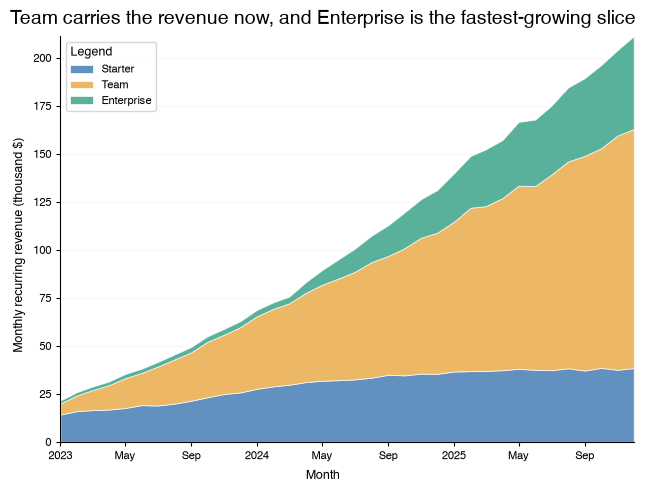

In [3]:
mrr_figure = StackedAreaChart(
    [[{"x": month, "y": value} for month, value in zip(MONTHS, mrr[plan])] for plan in PLANS],
    title="Team carries the revenue now, and Enterprise is the fastest-growing slice",
    xlabel="Month",
    ylabel="Monthly recurring revenue (thousand $)",
    subtitle=PLANS,
    show_legend=True,
    legend={"location": LEGEND_LOCATION.UPPER_LEFT},
    show_grid=SHOW_GRID.Y,
    figsize=FIG_SIZE.FULL_MEDIUM,
)
mrr_figure.show()

Monthly recurring revenue grew from about 22 thousand dollars to 211 thousand over the three years, and the bands say how. Starter, the self-serve plan, carried the first year and then flattened: its band is the same thickness in 2025 as in mid-2024. Team overtook it in July 2023 and has widened since, and Enterprise, a sliver until the sales team arrived in early 2024, is the band growing fastest at the right edge. The mix shifted from self-serve to sold, and the rest of the review explains how.

### Which segments carry it?

A year's revenue by region and industry is a table of 23 cells that a reader cannot rank at a glance; a [treemap](../../how-to-guides/charts/treemap/) draws each cell as a rectangle proportional to its revenue, nested inside its region, so the largest segments are the largest areas and the regions compare by outline. The records nest the same way (a region record with `children` for its industries), and `show_values` prints each leaf's revenue in its cell.

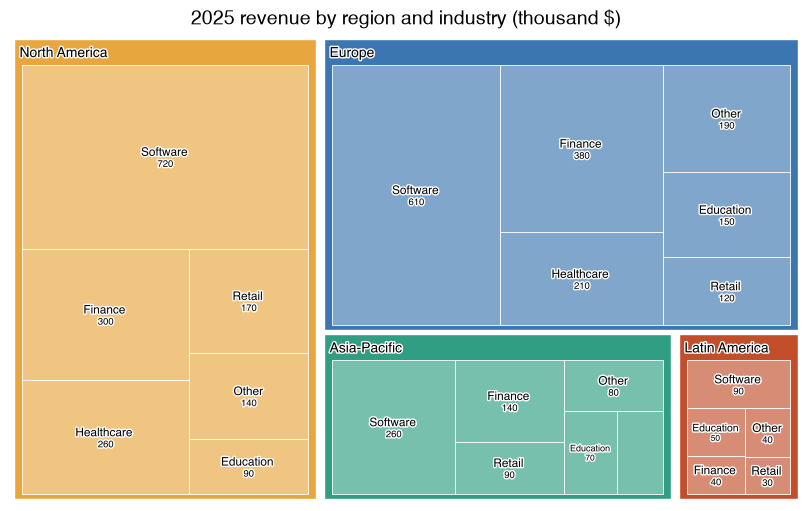

In [4]:
segments_figure = Treemap(
    {
        "data": [
            {
                "label": region,
                "children": [
                    {"label": industry, "value": revenue}
                    for industry, revenue in industries.items()
                ],
            }
            for region, industries in REGIONS.items()
        ]
    },
    title="2025 revenue by region and industry (thousand $)",
    show_values=True,
    value_format=VALUE_FORMAT.THOUSANDS,
    figsize=(8.0, 5.0),
)
segments_figure.show()

Europe and North America are almost equal and together hold 78% of the revenue; Asia-Pacific is a third the size of either and Latin America a sliver. The same industry leads in every region: software customers bring 39% of all revenue, and finance is second everywhere except Latin America. That concentration is a strength in a sales deck and a risk in a board pack.

### Which channels bring the customers, and has the order changed?

Six acquisition channels over eight quarters is a ranking that changes, and a [bump chart](../../how-to-guides/charts/bumpchart/) draws exactly that: one line per channel, its vertical position each quarter is its rank by new customers, and a line that climbs is a channel overtaking the others. The chart ranks the raw counts itself, so the records carry the counts and `subtitle` names the lines at their ends. The quarters are given as their index on the `x` axis and named with `xticklabels`.

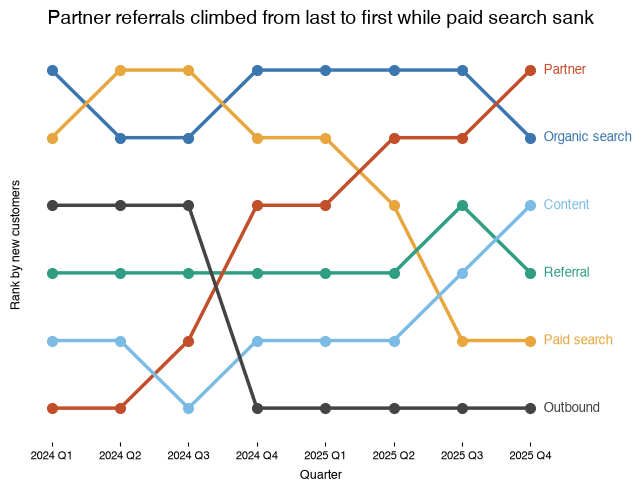

In [5]:
channels_figure = BumpChart(
    [
        [{"x": index, "y": count} for index, count in enumerate(new_customers[channel])]
        for channel in CHANNELS
    ],
    title="Partner referrals climbed from last to first while paid search sank",
    xlabel="Quarter",
    ylabel="Rank by new customers",
    subtitle=CHANNELS,
    xticks=list(range(len(QUARTERS))),
    xticklabels=QUARTERS,
    figsize=FIG_SIZE.FULL_MEDIUM,
)
channels_figure.show()

In the first quarter of 2024 the order was organic search, paid search and outbound; by the last quarter of 2025 it is partner, organic search and content. The partner line crosses every other line on its way up and the paid-search line crosses four on its way down: the marketing budget moved from advertising to the partner programme, and the customers followed. Content climbed too, more quietly, and referral held its place.

## Acquisition and retention

### Where do prospective customers drop out?

A funnel is a sequence of steps that each lose people, and the question is which step loses most. A [Sankey chart](../../how-to-guides/charts/sankeychart/) draws every step as a flow whose width is its count, so the thinning of the paid stream from left to right is the funnel itself and each branch that leaves it is a drop-out reason. The `links` are the steps as (source, target, value) records, `column_labels` names the stages along the top, and `show_values` prints the counts on the nodes. The funnel starts at the sign-up: the 240,000 visitors before it would be a flow twelve times wider than everything after, and the chart would show nothing else.

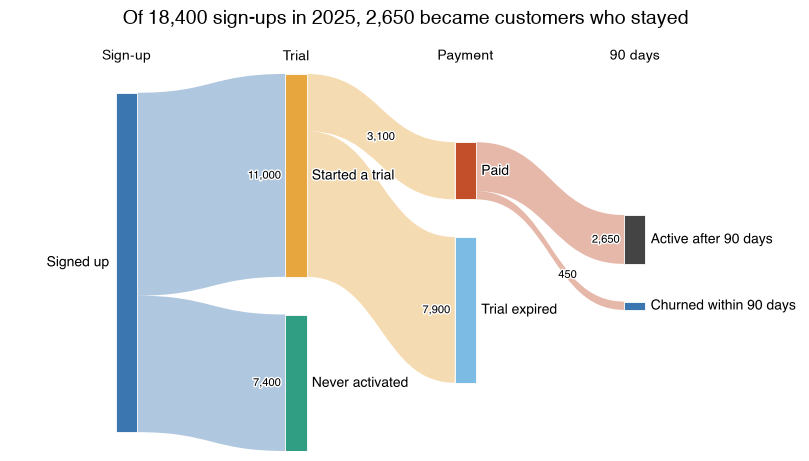

In [6]:
funnel_figure = SankeyChart(
    {"links": [{"source": source, "target": target, "value": people} for source, target, people in FUNNEL]},
    title="Of 18,400 sign-ups in 2025, 2,650 became customers who stayed",
    column_labels=["Sign-up", "Trial", "Payment", "90 days"],
    show_values=True,
    value_format=VALUE_FORMAT.THOUSANDS,
    figsize=(8.0, 4.5),
)
funnel_figure.show()

Only 8% of visitors sign up at all, which is normal for a marketing site and not where the fix is. The trial is the step to worry about: 72% of the people who start one let it expire, a bigger loss than the 40% who sign up and never activate. Once someone pays, 85% are still paying after 90 days. The trial step is where the onboarding work on the roadmap comes from, and the retention figure below is where its effect shows.

### When do people sign up?

Daily counts over a year carry three rhythms at once (the week, the seasons and the one-off events), and a line of 365 points shows none of them clearly. A [calendar heatmap](../../how-to-guides/charts/calendarheatmap/) lays the year out as a calendar, one cell per day coloured by its count, so weekends read as pale rows, holidays as pale columns and a launch as a dark stripe. The records are two parallel lists, `date` and `value`, and a wide figure with `aspect_ratio=ASPECT_RATIO.AUTO` stretches the cells to fill it. One event at three times the usual rate would push every ordinary day into the palest shades, so `vmax` caps the colour scale below it: the launch saturates and the rest of the year keeps its contrast.

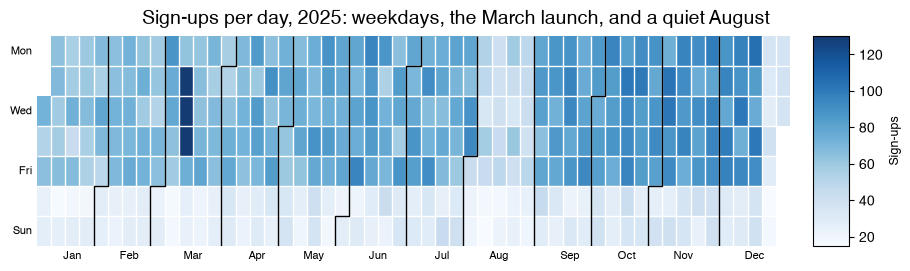

In [7]:
signups_figure = CalendarHeatmap(
    {"date": DAYS, "value": signups.tolist()},
    title="Sign-ups per day, 2025: weekdays, the March launch, and a quiet August",
    figsize=(9.0, 2.6),
    aspect_ratio=ASPECT_RATIO.AUTO,
    # cap the scale so the launch saturates instead of washing out the rhythm
    vmax=130,
    show_colorbars=True,
    colorbar={"label": "Sign-ups"},
)
signups_figure.show()

Weekdays average 75 sign-ups and weekends 28, so the two pale rows at the bottom of every month are Saturday and Sunday. The dark stripe in the second week of March is the launch, three days at three times the usual rate; August is pale throughout and the last week of December nearly white. The cells also darken slowly from left to right, which is the growth of the product showing through the noise. A support team reads its staffing off this figure, and a marketing team reads which campaign moved the numbers.

### Do the customers who pay stay?

Revenue can grow while every cohort leaks, as long as new customers arrive faster than old ones leave; the check is to follow each month's new paying customers on their own and count how many are still paying one, two, three months later. Twelve cohorts by twelve months is a triangle (the January cohort has eleven months of history, the December cohort none), and a [heatmap](../../how-to-guides/charts/heatmap/) draws it with `None` for the cells that have not happened yet, `show_values` printing the retained share in each cell, and `value_format` giving it a percent sign. Reading down a column compares cohorts at the same age, which is how an onboarding change shows up.

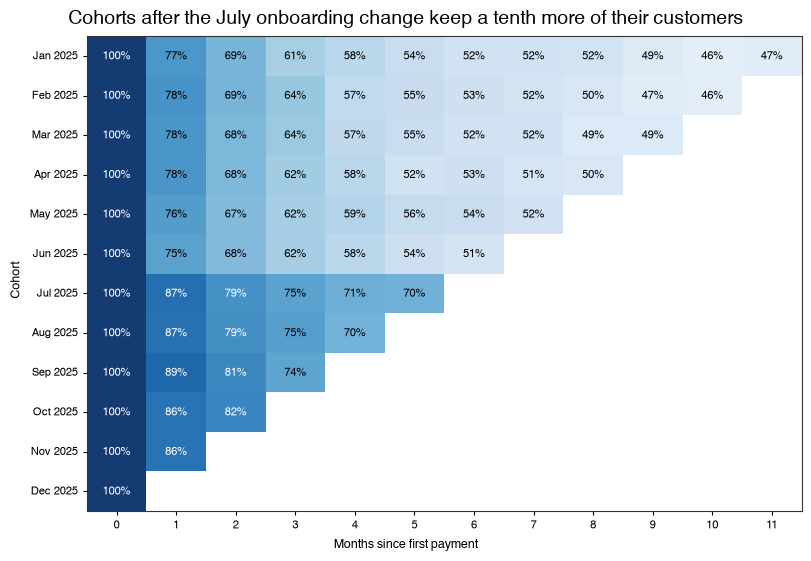

In [8]:
cohort_figure = Heatmap(
    {
        "x": list(range(12)),
        "y": [cohort.strftime("%b %Y") for cohort in COHORTS],
        "z": retention,
    },
    title="Cohorts after the July onboarding change keep a tenth more of their customers",
    xlabel="Months since first payment",
    ylabel="Cohort",
    show_values=True,
    value_format="{x:.0f}%",
    vmin=40,
    vmax=100,
    figsize=(8.0, 5.5),
)
cohort_figure.show()

Every row falls fastest in its first month and then flattens, which is the usual shape: the customers who were going to leave mostly leave at once. The rows split into two families. The January to June cohorts keep about 61% of their customers at three months; the July cohort onwards keeps about 75% at the same age, and the step is visible as a colour boundary between the June and July rows in every column. The guided setup that shipped in July is the difference, and this figure is the evidence a product team brings when it asks for more of the same.

## Planning

### What ships when, and what is late?

A roadmap is a set of tasks with dates, owners and dependencies, and the figure for it is the [Gantt chart](../../how-to-guides/charts/ganttchart/): one bar per task from its start to its end, grouped by team, with a filled portion for the progress made and arrows for what waits on what. `show_today` draws today's line, which is the point of the figure in a review: a bar that has not filled up to the line is behind. `period` sets the axis grain, and `show_values` prints each bar's progress.

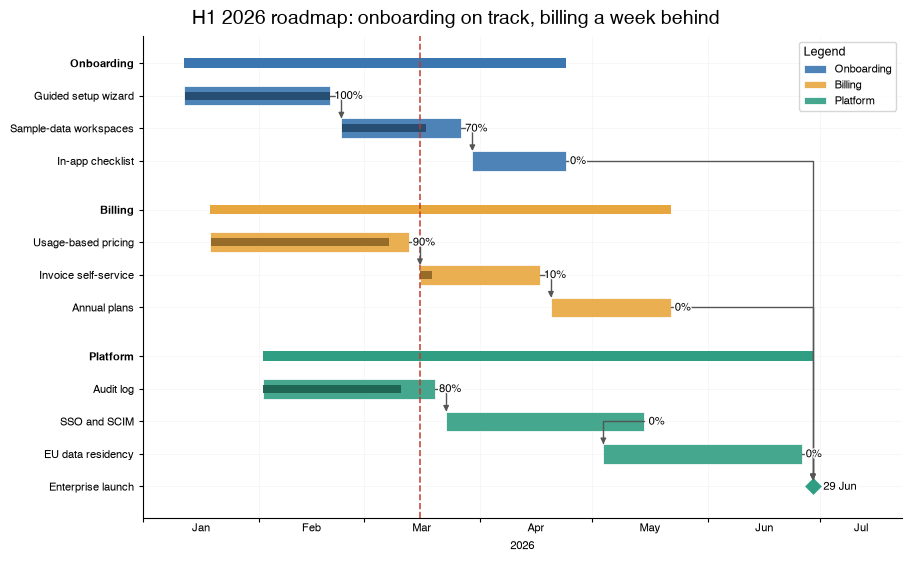

In [9]:
roadmap_figure = GanttChart(
    ROADMAP,
    title="H1 2026 roadmap: onboarding on track, billing a week behind",
    period=GANTT_DATE_PERIOD.MONTH,
    show_today=True,
    today=TODAY,
    show_dependencies=True,
    show_group_headers=True,
    show_values=True, value_kind=GANTT_VALUE.PROGRESS,
    show_legend=True,
    figsize=(9.0, 5.5),
)
roadmap_figure.show()

The onboarding track is on schedule: the wizard is done, and the sample workspaces are 70% through with a week and a half to go. Billing is the track to watch. Usage-based pricing should have finished last Friday and is at 90%, so the invoice work that depends on it starts late, and the annual plans behind that slip with it. The platform track's audit log is on time, but the enterprise launch at the end of June waits on all three tracks, and the arrows converging on it show which one it waits for. The launch date belongs to the slowest chain.

## The review figure

A quarterly review has room for one figure, not eight. The four that carry the story (the revenue mix, the channel ranks, the retention step, and the funnel) go into one panel with [Grid](../../how-to-guides/utility/grid/), which takes the figures already drawn above and redraws them into its cells. Nested lists are the layout, one inner list per row.

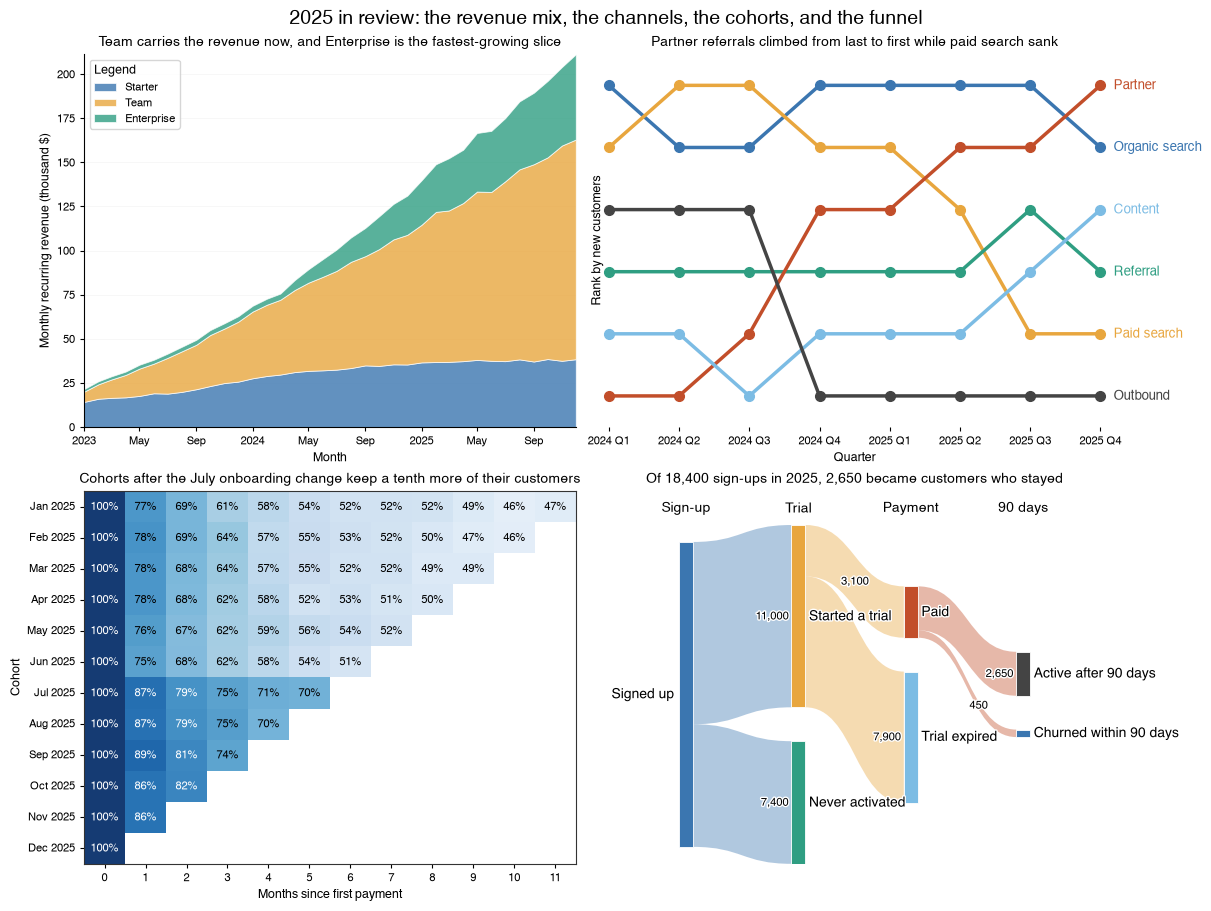

In [10]:
Grid(
    [
        [mrr_figure, channels_figure],
        [cohort_figure, funnel_figure],
    ],
    title="2025 in review: the revenue mix, the channels, the cohorts, and the funnel",
    figsize=(12.0, 9.0),
).show()

Every figure on this page is one call to a chart function over a list of dicts, and every number in them comes from a few lines of numpy written out in the hidden cell at the top. To adapt any of them, open the guide it links to and read the parameter that does the job; the [annotations guide](../../how-to-guides/utility/annotations/) covers the reference lines and notes the figures can carry. The charts index lists them all: [Charts](../../how-to-guides/charts/).